In [13]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [14]:
real_bars = pd.read_csv('/Users/rm026/Documents/msa/msa_local_filelist_w_baseline_info.csv')
ground_truth = pd.read_csv('/Users/rm026/Documents/code/reviewpyper_testing/unredacted_msa_ground_truth_w_maybes.csv')
ground_truth.replace({2:0}, inplace=True)
ground_truth.columns=['MRN','Fake_MRN','gait','heel-shin','finger-nose','dysarthria','oculomotor']
qs={'gait':8, 'heel-shin':4, 'finger-nose':4, 'dysarthria':4, 'oculomotor':2}
weighted_cols=[]
for question, weight in qs.items():
    # merged
    ground_truth[f'{question}_weighted']=ground_truth[question]*weight
    weighted_cols.append(f'{question}_weighted')
ground_truth['estimated_bars']=ground_truth[weighted_cols].sum(axis=1)
ground_truth

,MRN,Fake_MRN,gait,heel-shin,finger-nose,dysarthria,oculomotor,gait_weighted,heel-shin_weighted,finger-nose_weighted,dysarthria_weighted,oculomotor_weighted,estimated_bars
0,10087609,1,1,1,1,1,1,8,4,4,4,2,22
1,18337527,0,1,1,1,1,1,8,4,4,4,2,22
2,22159321,3,1,1,1,1,0,8,4,4,4,0,20
3,22171516,4,1,1,1,1,1,8,4,4,4,2,22
4,26860551,5,1,1,1,1,0,8,4,4,4,0,20
5,29828050,6,1,0,1,0,1,8,0,4,0,2,14
6,33585787,7,1,0,0,1,1,8,0,0,4,2,14
7,39983424,8,1,0,1,1,1,8,0,4,4,2,18
8,40204844,9,1,0,1,1,1,8,0,4,4,2,18
9,42261594,10,1,1,1,1,1,8,4,4,4,2,22


In [15]:
mylist=[]
for sub in real_bars['MRN'].unique():
    mydf=real_bars[real_bars['MRN']==sub]
    max_bars=mydf['BARS'].max()
    
    if np.isnan(max_bars):
        continue
    fakes=ground_truth[ground_truth['MRN']==sub]['estimated_bars']
    if len(fakes)==0:
        print(sub)
        continue

    mylist.append([sub, mydf['BARS'].max(), fakes.values[0]])
merged=pd.DataFrame(mylist, columns=['mrn','bars','estimated_bars'])
merged

15577414
26815373


,mrn,bars,estimated_bars
0,10087609,29.6,22
1,18337527,10.5,22
2,22159321,23.0,20
3,22171516,20.5,22
4,29828050,1.0,14
5,33585787,8.0,14
6,40204844,11.0,18
7,42261594,18.5,22
8,42862441,5.0,22
9,43675339,17.0,22


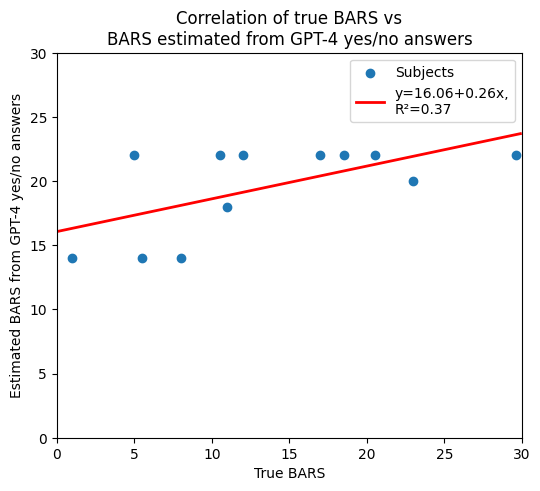

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))


ax.scatter(merged['bars'], merged['estimated_bars'])
plt.xlabel('True BARS')
plt.ylabel('Estimated BARS from GPT-4 yes/no answers')
plt.title('Correlation of true BARS vs\nBARS estimated from GPT-4 yes/no answers')
plt.ylim(0, 30)
plt.xlim(0, 30)
# Fit linear regression via least squares with numpy.polyfit
# It returns an slope (b) and intercept (a)
# deg=1 means linear fit (i.e. polynomial of degree 1)
b, a = np.polyfit(merged['bars'], merged['estimated_bars'], deg=1)

# Create sequence of 100 numbers from 0 to 100
xseq = np.arange(0,30,.1 )

# Plot regression line
ax.plot(xseq, a + b * xseq, color='red', lw=2)
ax.legend(['Subjects',f'y={a:.2f}+{b:.2f}x,\nR²={np.corrcoef(merged["bars"], merged["estimated_bars"])[0,1]**2:.2f}'])
plt.savefig('/Users/rm026/Documents/code/reviewpyper_testing/plots/bars_binary_correl_to_truth_plot.png', dpi=300)

In [ ]:
b

0.011530002061997379

In [ ]:
import statsmodels.api as sm
model = sm.GLM(merged['bars'], merged['psuedo-bars'], family=sm.families.Gaussian())

results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   bars   No. Observations:                   12
Model:                            GLM   Df Residuals:                       11
Model Family:                Gaussian   Df Model:                            0
Link Function:               Identity   Scale:                          52.751
Method:                          IRLS   Log-Likelihood:                -40.299
Date:                Wed, 08 Oct 2025   Deviance:                       580.26
Time:                        17:05:47   Pearson chi2:                     580.
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2686
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
psuedo-bars    15.9188      2.374      6.706      